In [1]:
#%pip install transformers

In [2]:
#%pip install torch --index-url https://download.pytorch.org/whl/cu121 - this didn't work on my machine but maintain this for online pipeline
#%pip3 install torch torchvision - this was done for my machine, not required for online pipeline

In [3]:
#%pip install scikit-learn

In [4]:
import csv

from transformers import pipeline
# import plotly as plt
from tqdm import tqdm
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA


In [5]:
#clf = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") # The original model
clf = pipeline("zero-shot-classification", model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0", device="mps") # the model with the best results, device="mps" not for the online pipeline
#clf = pipeline("zero-shot-classification", model="cross-encoder/nli-MiniLM2-L6-H768",device="mps") # tried, not performative

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

In [6]:
# Answering a question by garo - this is a test of the model
result = clf("assault", ['crime', 'safety', 'climate'], multi_label=True)
result

{'sequence': 'assault',
 'labels': ['crime', 'safety', 'climate'],
 'scores': [0.9984052777290344, 0.00016799535660538822, 9.685608529252931e-05]}

In [7]:
#this is another test of the model
seq = "hello world!"
candidate_labels = ["greeting", "food"]
result = clf(seq, candidate_labels, multi_label=True)
result

{'sequence': 'hello world!',
 'labels': ['greeting', 'food'],
 'scores': [0.9996812343597412, 9.647850674809888e-05]}

In [8]:
#This cell is where the most recent list of tags are imported to be processed
import requests
import io

# filename = '/kaggle/input/datasets/jeromegv/normalized-subject-terms-txt/normalized_subject_terms.txt'
# subject_terms = []
# with open(filename, 'r', encoding='utf-8') as file:
#     subject_terms = file.readlines()
# subject_terms = [term.strip() for term in subject_terms]

#github_url = "https://raw.githubusercontent.com/civic-dashboard/civic-dashboard-web/375tagginguireal/normalized_subject_terms.txt"
github_url = "https://raw.githubusercontent.com/civic-dashboard/civic-dashboard-web/main/ml/input/subject_terms.txt"
response = requests.get(github_url)

if response.status_code == 200:
    subject_terms = [term.strip() for term in response.text.splitlines() if term.strip()]
    print(f"Successfully loaded {len(subject_terms)} terms from GitHub.")
else:
    print(f"Failed to fetch file. Status code: {response.status_code}")

subject_terms[:5]

Successfully loaded 3717 terms from GitHub.


['20-minute makeover', '25 year club', '3 rs', '3-1-1', '311']

In [9]:
# Those are the list of tentative tags we are trying against the list of normalized subject terms
# This is tracked by this github ticket: https://github.com/civic-dashboard/civic-dashboard-web/issues/139
#These new tags were agreed upon after meeting as a group on June 2, 2026
#The difference between this and the notebook that TH downloaded on May 11 is 1)There are 28 categories instead of 20 2) the categories are now in a dict instead of a list and the model is given a rich description rather than the category name

category_descriptions = {
    "Accessibility": "Accessibility: This is about accessibility for people with disabilities (the disabled), such as wheel-trans, wheelchairs,mobility aids, accessible parking permits, AODA, barrier-free design, accessible taxis, acessible parking, and mobility devices. Inputs that contain accessible or disabled as descriptors belong here, NOT in Governance & City Hall.",
    "Animals & Wildlife": "Animals & Wildlife: Concerns about wild animals in urban or suburban areas, including animal sightings, injured or sick wild animals, and wildlife removal or deterrence. Covers all wild animals including raccoons, coyotes, skunks, snakes, squirrels, bats, deer, foxes, chickens, and wild birds (geese, gulls, pigeons). Also covers integrated pest management programs for rodents and invasive species. Excludes domestic pets (cats and dogs). Excludes natural habitat preservation.",
    "Arts, Culture & Events": "Arts, Culture & Events: This is about arts, culture, events, and tourism, such as Canadian National Exhibition (CNE), festivals, museums, public art, theatres, concerts, exhibitions, events, and cultural organizations.",
    "Biking":"Biking: This is about bikes, cycles, and bicycles, including bike trails.",
    "Budget, Taxes & Finance": "Budget, Taxes & Finance: This is about city finances, revenue generation, taxes, and fees, such as institutional taxes, budgets, audits, financial reports, grants, user fees, fines, land transfer tax, billing, development charges, parking revenue, and tax rebates. All inputs related to revenue, budgets and finances belong here NOT in Governance & City Hall.",
    "Business & Economy": "Business & Economy: This is about businesses and economic development, such as business improvement areas (also as bia), restaurants, cafes, retail stores, biotech, food & beverage industries,industrial parks, factories, tech hubs, film industry, investment attraction, 20-minute makeover, and commercial districts.",
    "Children & Youth": "Children & Youth: This is about programs or services for children and youth, such as childcare, daycare, camps, early childhood education, youth justice, and youth programs.",
    "City Employment": "City Employment: This is about the city as an employer such as hiring, collective bargaining, employee relations, staff training, service awards, job, labor, labour, and years of service recognition.",
    "Community & People": "Community & People: This is about city-funded programs that support residents and neighbourhoods. Includes neighbourhood associations, resident panels, community outreach workers, community benefit agreements, civic engagement programs, religious communities, religious diversity, food banks, shelters, poverty reduction, income support, adult literacy programs, adult education, employment assistance, and college or continuing education programs. NOT arts festivals, recreational events, or city governance processes.",
    "Construction & Infrastructure": "Construction & Infrastructure: This is about the physical building, repair, or maintenance of city structures, overpasses, and roads — the construction work itself, not traffic flow. Includes pothole repairs, road resurfacing, road widening, road alterations, road reconstruction, retaining walls, bollards, bridge reconstruction, sidewalk maintenance, building retrofits, restoration of structures, concrete work, construction deposits, heavy machinery and construction trucks, and capital infrastructure projects. Does NOT include traffic signals, lane management, or vehicle movement — those belong in Traffic.",
    "Climate": "Environment & Climate: This is about the natural environment, climate, pollution; such as trees, urban forestry, air quality, climate change adaptation, green energy, native species, biodiversity, ecological conservation, ravine protection, clean-city, and greenhouse gas reduction. Does not include water infrastructure, sewers, or waste collection.",
    "Equity": "Equity: This is about equity, social inclusion and human rights and contains terms to describe people that are not white heterosexual males such as minorities, sex & gender, gender identity, LGBTQ, sexism, bisexual, transgendered, immigration, refugees, racial discrimination, racism, indigenous, inuit, metis, First Nations, Indian, Native, racialized peoples. This group also includes the terms around inclusion such as pay equity.",
    "Governance & City Hall": "Governance & City Hall: This is about Toronto city hall, its elected officials, and city council activities. Includes the mayor, city councillors, members of council, alderwomen, elected officials, elected representatives, council decisions, local government, bylaws, legislation, municipal elections, ward boundary reviews, advisory committees, ombudsman, integrity commissioner, and intergovernmental cooperation. NOT about specific policy areas like housing, zoning, health, drinking water,employee agreements,or transit — only the people and actions of city government itself.",
    "Housing & Homelessness": "Housing & Homelessness: This is about housing or homelessness, such as affordable housing, below-market rent, shelters, encampments, rooming houses, tenants, rent subsidies, public housing (TCHC), and warming centres.",
    "Parks & Green Spaces": "Parks & Green Spaces: Parks & Green Spaces: This is about the city's outdoor public land — its parks, natural areas, and green infrastructure. This is about parks, such as parkettes, ravines, beaches, rivers, dog parks, off-leash areas, leash-free zones playgrounds, splash pads, trails, skating rinks, invasive plants in parks, fauna, garden parks, and park maintenance. Does NOT include climate policy, wildlife control, or recreation centres.",
    "Pets": "This is about Cats and dogs as pets and their owners, such as dog and cat licences/licenses, dog tags, dog bites, lost or missing cats, lost or missing dogs, and pet bylaws. Does NOT include wild animals like raccoons or coyotes.",
    "Public Safety": "Public & Community Safety: This is about policing, fire, and emergency medical services, such as police, Toronto Police Service, fire services, paramedics, 911 calls, crime prevention, fire routes, and community violence reduction. Does not include general traffic or road safety.",
    "Public Health": "Public Health: This is about public health or health services, such as communicable diseases, infectious diseases, sexual health clinics, vaccinations, dental care, mental health, harm reduction, and health clinics.",
    "Public Transportation" : "All things related to public transportation including Toronto Transit Corporation (TTC), ridership, subways, light rail transit (LRT), ferries, buses, bus shelters, express routes, subway stations, streetcar.",
    "Seniors & Aging": "Seniors & Aging: This is about programs or facilities for seniors, such as long-term care (LTC) homes, nursing homes, senior programs, retirement homes, and home care.",
    "Service Requests & Nuisance Complaints": "Service Requests & Nuisance Complaints: 311 is the phone number to call the city for NON-EMERGENCY Service requests. This is about requesting a city service or reporting an issue through calling 311 or online service request channels. Also includes complaints such as noise complaints, construction noise, foul odours, smells, and light pollution.",
    "Sports & Recreation": "Sports & Recreation: This is about sports, recreation, or leisure facilities, such as arenas, pools, recreation centres, sports leagues & sports fields,skiing and ski hills, golf & golf courses, boating & docks, chess clubs, badminton, tennis,rinks,exercise, and fitness programs.",
    "Information & Libraries": "Information Disclosure & Libraries: This is about access to information through the Public Library (TPL) and acesss to city records, archives, and documents. It includes terms such as borrowing books, requesting digital records, publishing city records, freedom of information requests (FOI), request for disclosure, geographical & geospatial information (GIS) requests. Includes the library infrastructure such as library branches.",
    "Toronto Hydro & Utilities": "Toronto Hydro & Utilities: This is about electricity supply or hydro infrastructure, such as power outages, hydro bills, hydro poles, utility corridors, and electricity distribution & generation.",
    "Traffic": "Traffic: All things related to the movement of cars , whether private, taxis or ride share and traffic controls impacting traffic. This includes traffic signals, left-turn arrow, scramble light, speed bump, signalized intersections, red light cameras, amber light,  lane closures, HOV lanes, diamond lanes, lay-bys, lay bys, lane reduction, road conditions, sink holes, all-way stops, carpools, pedestrian crossings, towing, and road closures.",
    "Urban Planning & Zoning": "Urban Planning & Zoning: This is about how land in Toronto is designated, regulated, and developed — the physical shaping of the city. Includes zoning bylaws, zoning amendments, zoning amendment applications, minor variances, land use, land use designations, land owners and property rights, front yard parking regulations, landscape projects, site plan approvals, official plan amendments, neighbourhood plans, regional planning, reurbanization, urban design guidelines, heritage preservation, Committee of Adjustment, and development applications. ",
    "Waste Management": "Waste Management: This is about collecting or disposing of solid waste, such as garbage (refuse) collection, recycling, green bin organics, blue bins,blue bin materials, biosolids, compost, landfills, landfill facilities, adopt-a-bin and waste diversion.",
    "Water & Sewers": "Water & Sewers: This is about drinking water supply, sewers, waste water, and drainage infrastructure, such as watermains, sewage treatment, sewer systems, stormwater, water meters, drinking water quality, water service connections, lead pipe replacement, floor drains, catch-basins, and basement flooding. Also includes water & sewer policy such as water restrictions, water quality reports, stormwater management, wastewater management.",
}

#These two line are required since categories is no longer a list
categories_short = list(category_descriptions.keys())
categories_verbose = list(category_descriptions.values())

In [10]:
#test case
seq = "3-1-1"
candidate_labels = list(category_descriptions.values())
result = clf(subject_terms[:100], candidate_labels, multi_label=True)
#result

In [11]:
#Commented out to make the notebook easier to read
#dict(zip(result[0]['labels'], result[0]['scores']))

In [12]:
# Compute similarities
# This is where the model uses the descriptions to assign each tag to a category.
#The hypothesis template and the context have been added to halp map the tags to categories.
#This is the most time consuming part, taking over 2 hours on TH laptop.
filename = 'similarities.csv'
hypothesis_template = "In Toronto municipal government, this topic relates to {}."


with open(filename, 'w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=['subject_term'] + categories_short)
    writer.writeheader()

    batch_index = 0
    batch_size = 200
    progress = tqdm(total=len(subject_terms))
    while batch_index * batch_size <= len(subject_terms):
        curr_term_batch = subject_terms[batch_index * batch_size:(batch_index + 1) * batch_size]

        # ← ADD THIS LINE: prepend municipal context to each term in the batch
        contextualized_batch = [f"Toronto City Council agenda topic: {t}" for t in curr_term_batch]

        results = clf(contextualized_batch, categories_verbose, multi_label=True, hypothesis_template=hypothesis_template)
        output = []
        for result, original_term in zip(results, curr_term_batch):
            score_map = dict(zip(result['labels'], result['scores']))
            row = {short: score_map[verbose] 
                   for short, verbose in zip(categories_short, categories_verbose)}
            row['subject_term'] = original_term  # ← keep the ORIGINAL term, not the contextualized one
            output.append(row)
        
        writer.writerows(output)
        progress.update(batch_size)
        batch_index += 1
    progress.close()

3800it [2:29:45,  2.36s/it]                                                                                             


In [13]:
def reduce_dimensionality(df: pd.DataFrame, num_dimensions: int) -> pd.DataFrame:
    pca = PCA(n_components=num_dimensions)
    pca.fit(df)
    reduced_df = pd.DataFrame(pca.transform(df))
    return reduced_df

In [14]:
df = pd.read_csv('similarities.csv')
df['max_val'] = df.drop(columns=['subject_term']).max(axis=1)
df['max_cat'] = df.drop(columns=['subject_term']).idxmax(axis=1)
df

,subject_term,Accessibility,Animals & Wildlife,"Arts, Culture & Events",Biking,"Budget, Taxes & Finance",Business & Economy,Children & Youth,City Employment,Community & People,...,Service Requests & Nuisance Complaints,Sports & Recreation,Information & Libraries,Toronto Hydro & Utilities,Traffic,Urban Planning & Zoning,Waste Management,Water & Sewers,max_val,max_cat
0,20-minute makeover,0.000834,0.001915,0.016014,0.011464,0.000722,0.037222,0.004792,0.001090,0.000880,...,0.000718,0.004007,0.001088,0.001193,0.001142,0.006109,0.002341,0.005070,0.037222,Business & Economy
1,25 year club,0.000555,0.003531,0.012674,0.007135,0.000871,0.002132,0.003016,0.022180,0.001022,...,0.000728,0.004408,0.002055,0.005786,0.001149,0.004126,0.002170,0.005051,0.022180,City Employment
2,3 rs,0.001116,0.023398,0.026106,0.013875,0.002668,0.009431,0.013769,0.009250,0.009055,...,0.009179,0.030821,0.010308,0.013197,0.012171,0.124852,0.011354,0.018654,0.124852,Urban Planning & Zoning
3,3-1-1,0.001259,0.020587,0.032131,0.026181,0.001988,0.014828,0.024493,0.013689,0.009413,...,0.007984,0.044225,0.008951,0.018493,0.015529,0.156814,0.010550,0.018618,0.156814,Urban Planning & Zoning
4,311,0.002208,0.018942,0.019069,0.009197,0.002075,0.009746,0.011115,0.008847,0.009268,...,0.008695,0.012408,0.010756,0.009394,0.010777,0.054199,0.009634,0.014714,0.054199,Urban Planning & Zoning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3712,zoning bylaws,0.001063,0.007025,0.003538,0.006811,0.000966,0.005080,0.000545,0.001188,0.000854,...,0.001238,0.007303,0.001793,0.001744,0.001282,0.210279,0.006401,0.008380,0.210279,Urban Planning & Zoning
3713,zoning designations,0.000868,0.004015,0.004118,0.006864,0.000843,0.006590,0.000380,0.001123,0.000784,...,0.000908,0.006667,0.001601,0.002055,0.000497,0.192919,0.005374,0.005911,0.192919,Urban Planning & Zoning
3714,zoning project,0.001233,0.005708,0.008109,0.011778,0.001163,0.007984,0.001001,0.001543,0.001158,...,0.001262,0.012625,0.001923,0.006552,0.000841,0.072243,0.005100,0.008062,0.072243,Urban Planning & Zoning
3715,zoo animals,0.000372,0.003992,0.004583,0.000332,0.000336,0.000314,0.001835,0.000531,0.000519,...,0.000496,0.000594,0.000538,0.000243,0.000275,0.000958,0.000369,0.001002,0.004583,"Arts, Culture & Events"


In [15]:
# Add subject term frequency
from collections import Counter
import numpy as np

# subject_term_counter = Counter()
# with open("/kaggle/input/datasets/jeromegv/normalized-subject-terms-txt/normalized_subject_terms.txt", 'r', encoding='utf-8') as file:
#     for line in file:
#         term = line.strip()
#         subject_term_counter[term] += 1

# Since we already fetched the list from GitHub in Cell 8, we use it directly:
subject_term_counter = Counter(subject_terms)

df['frequency'] = 0
frequencies = []
for i, row in df.iterrows():
    frequencies.append(subject_term_counter[row['subject_term']])
df['frequency'] = frequencies
assert df['frequency'].all()

df['log_frequency'] = np.log(df['frequency'])
#df

In [16]:
reduced_df = pd.DataFrame(df)
reduced_df.drop(columns=['subject_term', 'max_val', 'max_cat'], inplace=True)
reduced_df = reduce_dimensionality(reduced_df, 3)
reduced_df.insert(0, 'subject_term', pd.Series(df['subject_term']))
reduced_df

,subject_term,0,1,2
0,20-minute makeover,-0.010502,-0.013839,-0.012828
1,25 year club,-0.014679,-0.012757,-0.014226
2,3 rs,-0.001937,0.016324,0.051779
3,3-1-1,0.011305,0.029181,0.153762
4,311,-0.010714,-0.002485,0.033913
...,...,...,...,...
3712,zoning bylaws,-0.013935,-0.006009,0.039939
3713,zoning designations,-0.014098,-0.007113,0.033762
3714,zoning project,-0.008169,-0.004423,0.004837
3715,zoo animals,-0.022260,-0.015647,-0.020007


In [17]:
#fig = px.scatter_3d(reduced_df, x=0, y=1, z=2, hover_name='subject_term')
#fig.show()

In [18]:
#fig = px.scatter_matrix(df, dimensions=categories_short[:5], width=1600, height=800, hover_name='subject_term')
#fig.show()

In [19]:
print(df.shape)  # how many rows are going into fit_transform?

(3717, 33)


In [20]:
#del clf
import gc
gc.collect()
# If using MPS/PyTorch:
import torch
torch.mps.empty_cache()

In [21]:
# ── Post-processing: rule-based corrections ──────────────────────────────────

# Rule 1: Pets
pets_mask = (
    (df['subject_term'].str.contains(r'\bcat\b|\bdog\b|\bpet\b', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Pets')
)
df.loc[pets_mask, 'max_cat'] = 'Pets'
df.loc[pets_mask, 'max_val'] = 1.0
print(f"Rule 1 (Pets): {pets_mask.sum()} terms corrected")

# Rule 2: Accessibility
accessibility_mask = (
    (df['subject_term'].str.contains('accessibility|barrier-free|disabled|disabilities|wheelchair|aoda|accessible|mobility', case=False, regex=True)) &
    (df['max_val'] < 1.0) &(df['max_cat'] != 'Accessibility')
)
df.loc[accessibility_mask, 'max_cat'] = 'Accessibility'
df.loc[accessibility_mask, 'max_val'] = 1.0
print(f"Rule 2 (Accessibility): {accessibility_mask.sum()} terms corrected")

# Rule 3: Budgets
budget_mask = (
    (df['subject_term'].str.contains('fees|taxes|grant|finance|financial|tax|levies|invoice|budget|charges|accounts payable|arrears', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Budget, Taxes & Finance')
)
df.loc[budget_mask, 'max_cat'] = 'Budget, Taxes & Finance'
df.loc[budget_mask, 'max_val'] = 1.0
print(f"Rule 3 (Budgets): {budget_mask.sum()} terms corrected")

# Rule 4: Water
water_mask = (
    (df['subject_term'].str.contains('water|sewer|flood|basement flooding|culverts', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Water & Sewers')
)
df.loc[water_mask, 'max_cat'] = 'Water & Sewers'
df.loc[water_mask, 'max_val'] = 1.0
print(f"Rule 4 (Water): {water_mask.sum()} terms corrected")

# Rule 5: Equity
equity_mask = (
    (df['subject_term'].str.contains('equity|bisexual|aboriginal|bilingual|First Nations|two spirited|gender', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Equity')
)
df.loc[equity_mask, 'max_cat'] = 'Equity'
df.loc[equity_mask, 'max_val'] = 1.0
print(f"Rule 5 (Equity): {equity_mask.sum()} terms corrected")

# Rule 6: Public Safety
PS_mask = (
    (df['subject_term'].str.contains('public safety|911|9-1-1|traffic casualties|traffic fatalities|collision|crashes|crisis response', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Public Safety')
)
df.loc[PS_mask, 'max_cat'] = 'Public Safety'
df.loc[PS_mask, 'max_val'] = 1.0
print(f"Rule 6 (Public Safety): {PS_mask.sum()} terms corrected")

# Rule 7: City Employment
CE_mask = (
    (df['subject_term'].str.contains('employee', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'City Employment')
)
df.loc[CE_mask, 'max_cat'] = 'City Employment'
df.loc[CE_mask, 'max_val'] = 1.0
print(f"Rule 7 (City Employmnet): {CE_mask.sum()} terms corrected")

# Rule 8: Climate
climate_mask = (
    (df['subject_term'].str.contains('environment|drive clean', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Climate')
)
df.loc[climate_mask, 'max_cat'] = 'Climate'
df.loc[climate_mask, 'max_val'] = 1.0
print(f"Rule 8 (Climate): {climate_mask.sum()} terms corrected")

# Rule 9: Service Requests & Nuisance Complaints
SR_mask = (
    (df['subject_term'].str.contains('311|3-1-1|complaints|noise', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Service Requests & Nuisance Complaints')
)
df.loc[SR_mask, 'max_cat'] = 'Service Requests & Nuisance Complaints'
df.loc[SR_mask, 'max_val'] = 1.0
print(f"Rule 9 (SR): {SR_mask.sum()} terms corrected")

# Rule 10: Construction & Infrastructure
CI_mask = (
    (df['subject_term'].str.contains('construction', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Construction & Infrastructure')
)
df.loc[CI_mask, 'max_cat'] = 'Construction & Infrastructure'
df.loc[CI_mask, 'max_val'] = 1.0
print(f"Rule 10 (CI): {CI_mask.sum()} terms corrected")

# Rule 11: Traffic
traffic_mask = (
    (df['subject_term'].str.contains('traffic|diamond lane|hov lane|pedestrian|left turn|layby|lay-by|laybys', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Traffic')
)
df.loc[traffic_mask, 'max_cat'] = 'Traffic'
df.loc[traffic_mask, 'max_val'] = 1.0
print(f"Rule 11 (Traffic): {traffic_mask.sum()} terms corrected")

# Rule 12: Business
business_mask = (
    (df['subject_term'].str.contains(r'business|convention cent|stores|cafes|industry|\bbia\b', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Business & Economy')
)
df.loc[business_mask, 'max_cat'] = 'Business & Economy'
df.loc[business_mask, 'max_val'] = 1.0
print(f"Rule 12 (Business): {business_mask.sum()} terms corrected")

# Rule 13: Waste Management
waste_mask = (
    (df['subject_term'].str.contains(r'blue bin|blue box|waste|collection routes|green bin|recycling|material recovery facilities|clothing bins', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Waste Management')
)
df.loc[waste_mask, 'max_cat'] = 'Waste Management'
df.loc[waste_mask, 'max_val'] = 1.0
print(f"Rule 12 (Waste): {waste_mask.sum()} terms corrected")

# Rule 14: Governance & City Hall
Gov_mask = (
    (df['subject_term'].str.contains('council|legislation|local government|executive committees', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Governance & City Hall')
)
df.loc[Gov_mask, 'max_cat'] = 'Governance & City Hall'
df.loc[Gov_mask, 'max_val'] = 1.0
print(f"Rule 14 (Governance): {Gov_mask.sum()} terms corrected")

# Rule 15: Sports & Recreation
SR_mask = (
    (df['subject_term'].str.contains('fitness|community cent', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Sports & Recreation')
)
df.loc[SR_mask, 'max_cat'] = 'Sports & Recreation'
df.loc[SR_mask, 'max_val'] = 1.0
print(f"Rule 15 (Sports & Recreation): {SR_mask.sum()} terms corrected")

# Rule 16: Arts, Culture & Events
ACE_mask = (
    (df['subject_term'].str.contains('festival', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Arts, Culture & Events')
)
df.loc[ACE_mask, 'max_cat'] = 'Arts, Culture & Events'
df.loc[ACE_mask, 'max_val'] = 1.0
print(f"Rule 16 (Arts, Culture & Events): {ACE_mask.sum()} terms corrected")

# Rule 17: Community & People
CP_mask = (
    (df['subject_term'].str.contains('community|neighbourhood|civic participation|civic engagement', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Community & People')
)
df.loc[CP_mask, 'max_cat'] = 'Community & People'
df.loc[CP_mask, 'max_val'] = 1.0
print(f"Rule 17 (Community): {CP_mask.sum()} terms corrected")

# Rule 18: Transportation
transportation_mask = (
    (df['subject_term'].str.contains(r'transportation|buses|go-peds|coach terminals|express|de-icing|transit|\bbus\b', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Public Transportation')
)
df.loc[transportation_mask, 'max_cat'] = 'Public Transportation'
df.loc[transportation_mask, 'max_val'] = 1.0
print(f"Rule 18 (Transportation): {transportation_mask.sum()} terms corrected")

# Rule 19: Urban Planning & Zoning
up_mask = (
    (df['subject_term'].str.contains('back alley|mews', case=False, regex=True)) &
    (df['max_val'] < 1.0) & (df['max_cat'] != 'Urban Planning & Zoning')
)
df.loc[up_mask, 'max_cat'] = 'Urban Planning & Zoning'
df.loc[up_mask, 'max_val'] = 1.0
print(f"Rule 19 (Urban Planning & Zoning): {up_mask.sum()} terms corrected")



Rule 1 (Pets): 7 terms corrected
Rule 2 (Accessibility): 36 terms corrected
Rule 3 (Budgets): 81 terms corrected
Rule 4 (Water): 27 terms corrected
Rule 5 (Equity): 11 terms corrected
Rule 6 (Public Safety): 11 terms corrected
Rule 7 (City Employmnet): 3 terms corrected
Rule 8 (Climate): 12 terms corrected
Rule 9 (SR): 10 terms corrected
Rule 10 (CI): 2 terms corrected
Rule 11 (Traffic): 28 terms corrected
Rule 12 (Business): 19 terms corrected
Rule 12 (Waste): 43 terms corrected
Rule 14 (Governance): 28 terms corrected
Rule 15 (Sports & Recreation): 1 terms corrected
Rule 16 (Arts, Culture & Events): 0 terms corrected
Rule 17 (Community): 51 terms corrected
Rule 18 (Transportation): 15 terms corrected
Rule 19 (Urban Planning & Zoning): 2 terms corrected


In [22]:
# Display top candidate subject terms for each category
threshold = 0.005
top_terms = df[df['max_val'] >= threshold]
#top_terms

In [23]:
top_terms.to_csv("top_terms.csv")

In [24]:
df.to_csv("all_terms.csv")

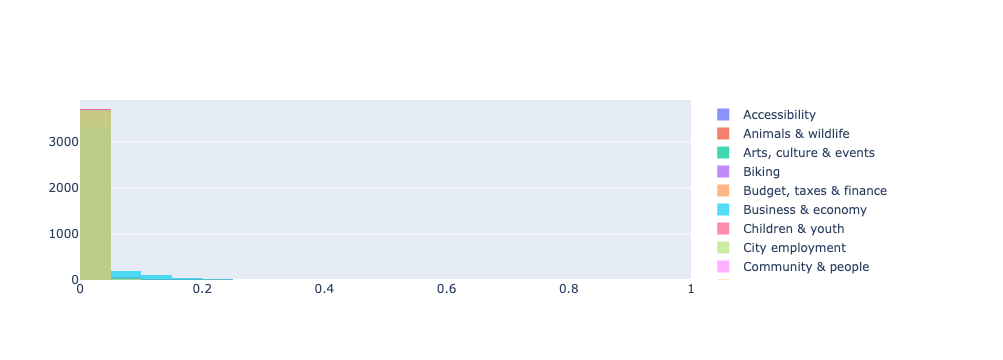

In [25]:
# Generate histograms of similarities per category
import plotly.graph_objects as go
import numpy as np

# fig = px.histogram(
#     df, 
#     x='housing',
#     width=500,
#     height=500,
#     nbins=20
# )
fig = go.Figure()
for cat in categories_short:
    fig.add_trace(go.Histogram(
        x=df[cat],
        xbins=dict(
            start=0.0,
            end=1.0,
            size=0.05
        ),
        name=cat.capitalize()
    ))
fig.update_layout(barmode='overlay', width=500)
fig.update_traces(opacity=0.75)
fig.show()

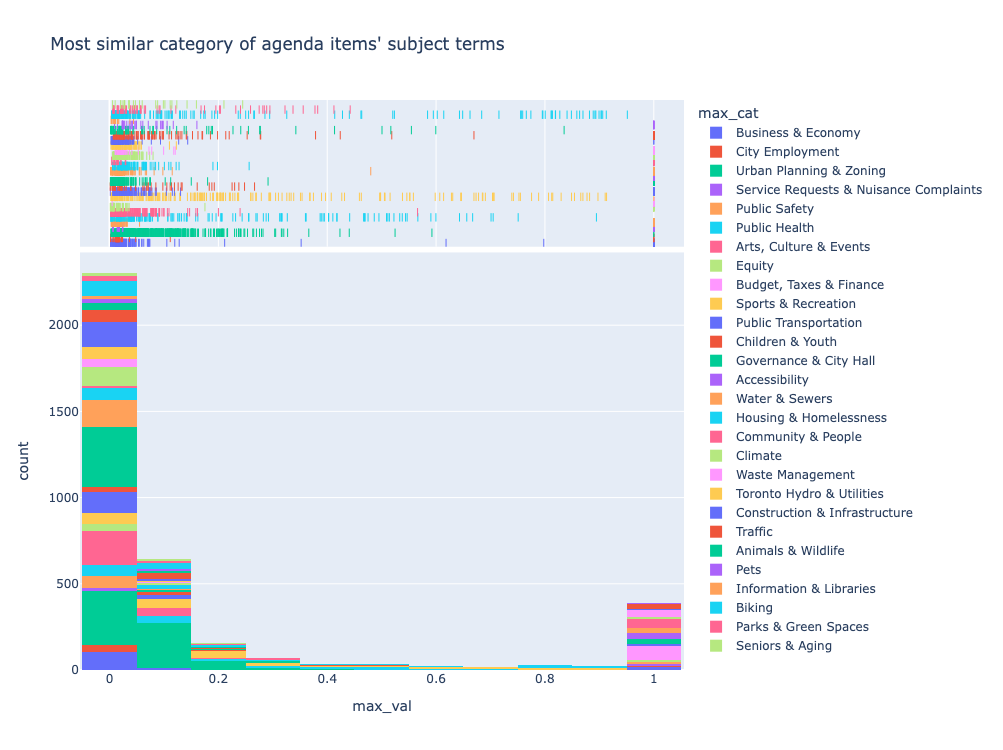

In [26]:
fig = px.histogram(
    df,
    x='max_val',
    color='max_cat',
    marginal='rug',
    hover_name='max_cat',
    width=1000,
    height=750,
    nbins=10,
    title='Most similar category of agenda items\' subject terms',
)
fig.show()

In [27]:
#for cat in categories_short:
#    fig = px.histogram(
#        df,
#        x=cat,
#        marginal='rug',
#        nbins=20,
#        width=500,
#        height=500,
#        # color='max_cat'
#    )
#    fig.show()

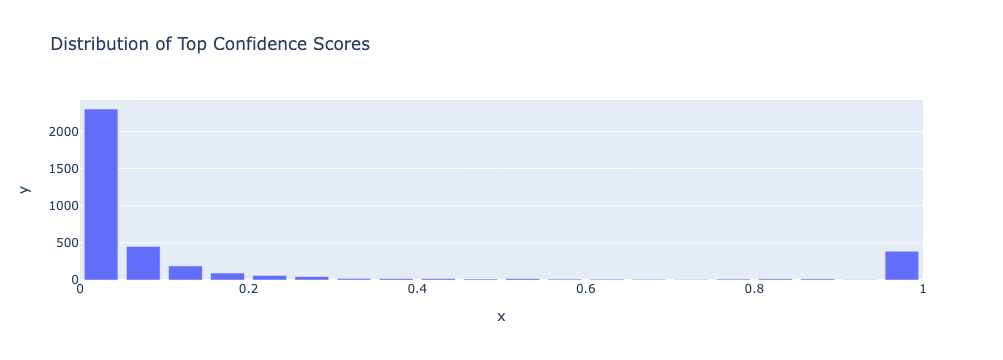

In [28]:
# FIX: Use 'max_val' instead of a specific category name
# This shows you the distribution of your model's "Best Guesses"
counts, bins = np.histogram(df['max_val'], bins=[i / 100 for i in range(0, 101, 5)])
bins = .5 * (bins[:-1] + bins[1:])
fig = px.bar(x=bins, y=counts, title="Distribution of Top Confidence Scores")
fig.show()

In [29]:
bins, counts

(array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
        0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875,
        0.925, 0.975]),
 array([2301,  453,  189,   94,   62,   45,   22,   19,   18,   14,   19,
          13,   12,   11,    8,   13,   15,   15,    6,  388]))

In [30]:
histogram_table = []
for cat in categories_short:
    counts, bins = np.histogram(df[cat], bins=[i / 100 for i in range(0, 101, 5)])
    histogram_table.append(counts.tolist())
    # bins = .5 * (bins[:-1] + bins[1:])
    # fig = px.bar(x=bins, y=counts)
    # fig.show()
histogram_table = pd.DataFrame(
    histogram_table,
    columns=[
        "0.00 - 0.05",
        "0.05 - 0.10",
        "0.10 - 0.15",
        "0.15 - 0.20",
        "0.20 - 0.25",
        "0.25 - 0.30",
        "0.30 - 0.35",
        "0.35 - 0.40",
        "0.40 - 0.45",
        "0.45 - 0.50",
        "0.50 - 0.55",
        "0.55 - 0.60",
        "0.60 - 0.65",
        "0.65 - 0.70",
        "0.70 - 0.75",
        "0.75 - 0.80",
        "0.80 - 0.85",
        "0.85 - 0.90",
        "0.90 - 0.95",
        "0.95 - 1.00"
    ],
    index=categories_short
)
#histogram_table

In [31]:
histogram_table.to_csv('histogram_table.csv')

In [32]:
sorted(categories_short)

['Accessibility',
 'Animals & Wildlife',
 'Arts, Culture & Events',
 'Biking',
 'Budget, Taxes & Finance',
 'Business & Economy',
 'Children & Youth',
 'City Employment',
 'Climate',
 'Community & People',
 'Construction & Infrastructure',
 'Equity',
 'Governance & City Hall',
 'Housing & Homelessness',
 'Information & Libraries',
 'Parks & Green Spaces',
 'Pets',
 'Public Health',
 'Public Safety',
 'Public Transportation',
 'Seniors & Aging',
 'Service Requests & Nuisance Complaints',
 'Sports & Recreation',
 'Toronto Hydro & Utilities',
 'Traffic',
 'Urban Planning & Zoning',
 'Waste Management',
 'Water & Sewers']

---

In [33]:
from collections import Counter

# count_terms = Counter()
# with open('/kaggle/input/datasets/jeromegv/normalized-subject-terms-txt/normalized_subject_terms.txt', 'r', encoding='utf-8') as file:
#     for line in file:
#         line = line.strip()
#         count_terms[line] += 1

# Using the pre-loaded data
count_terms = Counter(subject_terms)

In [34]:
sorted_terms = sorted(count_terms, reverse=True, key=lambda x: count_terms[x])

In [35]:
for term in sorted_terms:
    print(term, count_terms[term])

20-minute makeover 1
25 year club 1
3 rs 1
3-1-1 1
311 1
311 calls 1
9-1-1 1
911 1
911 calls 1
AIDS 1
Avenues 1
Canadian National Exhibition 1
Centres 1
Exhibition Place 1
First Nations 1
HIV 1
HIV/AIDS 1
Master Plans 1
Municipal Land Transfer Tax 1
Official Plans 1
Olympic Games 1
Secondary Plans 1
Toronto Transit Commission 1
abccs 1
abcds 1
aboriginal community 1
aboriginal peoples 1
aboriginal services 1
aboriginals 1
abuse 1
access requests 1
access toronto 1
accessibility 1
accessibility legislation 1
accessibility standards 1
accessible parking permits 1
accessible parking spaces 1
accessible permit parking 1
accessible public transportation 1
accessible taxicabs 1
accessible transit 1
accessible transit service 1
accessory apartments 1
accidental spills 1
accommodation providers 1
accommodation services 1
accountability 1
accounts 1
accounts payable 1
accounts receivable 1
accreditation 1
acquired immunodeficiency syndrome 1
acquisition 1
actions of government 1
activities in b

In [36]:
len(count_terms), df.shape

(3717, (3717, 33))

In [37]:
df.iloc[4000:4005]['subject_term'], sorted(count_terms)[4000:4005]

(Series([], Name: subject_term, dtype: str), [])

In [38]:
df['count'] = [count_terms[term] for term in sorted(count_terms)]
#df.iloc[4000:4005]

In [39]:
count_terms['smell']

1

In [40]:
df.to_csv('all_terms.csv')

In [41]:
# load in a validation file and create a dict

#df = pd.read_csv('/Users/tynahope/Documents/civic dashboard tags/ValidationJune3_325.csv')
df  = pd.read_csv('/Users/tynahope/Documents/civic dashboard tags/GT-TAH-June8.csv')
validation_labels = dict(zip(df['subject_term'], df['expected_category']))

validation_terms = list(validation_labels.keys())
validation_expected = list(validation_labels.values())

print(f"Loaded {len(validation_labels)} terms across {len(set(validation_expected))} categories")

Loaded 2700 terms across 28 categories


⚠️  67 validation term(s) not found in results — they will be excluded.

Overall accuracy: 76.6%  (2016/2633 correct)

                                        precision    recall  f1-score   support

                         Accessibility       0.97      0.74      0.84        47
                    Animals & Wildlife       0.73      0.95      0.82        37
                Arts, Culture & Events       0.70      0.84      0.76       129
                                Biking       0.47      0.96      0.63        48
               Budget, Taxes & Finance       0.74      0.56      0.64        93
                    Business & Economy       0.94      0.77      0.84       128
                      Children & Youth       0.89      0.74      0.81        46
                       City Employment       0.93      0.68      0.79        57
                               Climate       0.87      0.74      0.80       130
                    Community & People       0.66      0.54      0.60        72


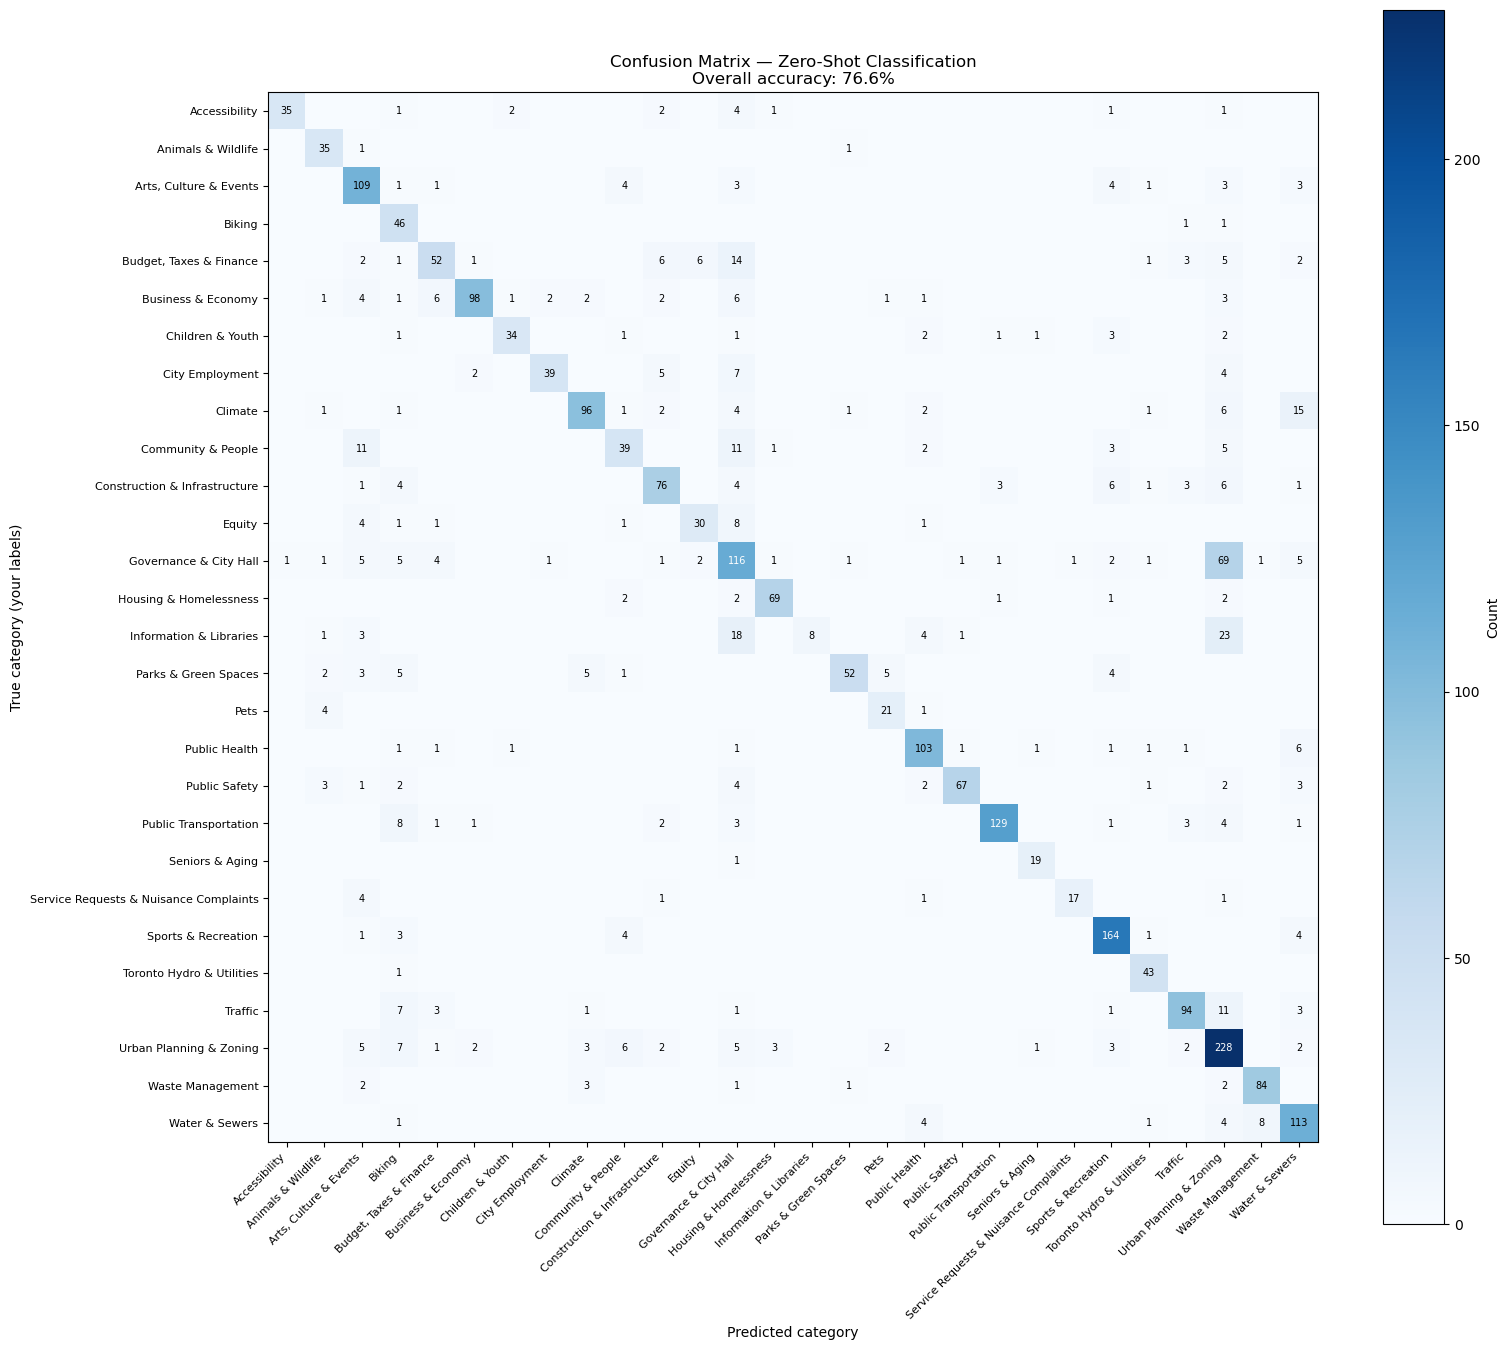

Confusion matrix saved to confusion_matrix.png

Top 15 confusions (true → predicted):
True category                       Predicted category                  Count
-----------------------------------------------------------------------------
Governance & City Hall              Urban Planning & Zoning                69
Information & Libraries             Urban Planning & Zoning                23
Information & Libraries             Governance & City Hall                 18
Climate                             Water & Sewers                         15
Budget, Taxes & Finance             Governance & City Hall                 14
Community & People                  Arts, Culture & Events                 11
Community & People                  Governance & City Hall                 11
Traffic                             Urban Planning & Zoning                11
Equity                              Governance & City Hall                  8
Public Transportation               Biking              

In [42]:
# ── Validation: Zero-Shot Classification vs. Manual Labels ──────────────────
# Paste this cell AFTER the cells that define:
#   - validation_labels  (from validation_set.py)
#   - the top_terms.csv results (adjust path below if needed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import classification_report, accuracy_score

# ── 1. Load classification results ──────────────────────────────────────────
results_path = "top_terms.csv"          # ← update path if needed
df_results = pd.read_csv(results_path)

# ── 2. Remap old category names in max_cat to current dict keys ─────────────
# (needed if the CSV was produced with a previous version of the categories)

df_results["predicted_category"] = df_results["max_cat"]

# ── 3. Build comparison dataframe from validation set ───────────────────────
df_val = pd.DataFrame(
    list(validation_labels.items()),
    columns=["subject_term", "expected_category"]
)

df_merged = df_val.merge(
    df_results[["subject_term", "predicted_category"]],
    on="subject_term",
    how="left"
)

missing = df_merged["predicted_category"].isna().sum()
if missing > 0:
    print(f"⚠️  {missing} validation term(s) not found in results — they will be excluded.")
    df_merged = df_merged.dropna(subset=["predicted_category"])

y_true = df_merged["expected_category"].tolist()
y_pred = df_merged["predicted_category"].tolist()

# ── 4. Overall accuracy ──────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
print(f"\nOverall accuracy: {acc:.1%}  ({int(acc * len(y_true))}/{len(y_true)} correct)\n")

# ── 5. Per-category report ───────────────────────────────────────────────────
print(classification_report(y_true, y_pred, zero_division=0))

# ── 6. Confusion matrix (heatmap) ───────────────────────────────────────────
all_cats = sorted(set(y_true) | set(y_pred))
n = len(all_cats)
cat_index = {c: i for i, c in enumerate(all_cats)}

matrix = np.zeros((n, n), dtype=int)
for true, pred in zip(y_true, y_pred):
    matrix[cat_index[true]][cat_index[pred]] += 1

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(matrix, cmap="Blues")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_cats, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(all_cats, fontsize=8)
ax.set_xlabel("Predicted category", fontsize=10)
ax.set_ylabel("True category (your labels)", fontsize=10)
ax.set_title(f"Confusion Matrix — Zero-Shot Classification\nOverall accuracy: {acc:.1%}", fontsize=12)

# Annotate cells that have values
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        if val > 0:
            colour = "white" if val > matrix.max() * 0.5 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=7, color=colour)

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to confusion_matrix.png")

# ── 7. Most common confusions (off-diagonal) ────────────────────────────────
print("\nTop 15 confusions (true → predicted):")
print(f"{'True category':<35} {'Predicted category':<35} {'Count':>5}")
print("-" * 77)
confusions = []
for i, true_cat in enumerate(all_cats):
    for j, pred_cat in enumerate(all_cats):
        if i != j and matrix[i, j] > 0:
            confusions.append((true_cat, pred_cat, matrix[i, j]))
confusions.sort(key=lambda x: -x[2])
for true_cat, pred_cat, count in confusions[:15]:
    print(f"{true_cat:<35} {pred_cat:<35} {count:>5}")

In [43]:
df_merged.to_csv("validation_out.csv")


In [44]:
score_lookup = df_results.set_index("subject_term")["max_val"]
df_merged["max_val"] = df_merged["subject_term"].map(score_lookup)
df_merged.to_csv("validation_out_withmaxval.csv")